# Approche C — STUNet + Velocity-Guided Timing-SAM
**Sara** : T5 encoder + diffusion DDIM + loss  
**Hiba** : STUNet + Timing-SAM + velocity injection

**Dataset :** How2Sign — 151 keypoints, séquences jusqu'à 440 frames

## 1. Setup — clone repo + imports

In [1]:
!git clone https://github.com/sarrazer24/sign-language-production.git
!pip install transformers sentencepiece dtaidistance -q

Cloning into 'sign-language-production'...


remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.


remote: Compressing objects: 100% (83/83), done.


remote: Total 115 (delta 61), reused 61 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 209.56 KiB | 3.55 MiB/s, done.
Resolving deltas: 100% (61/61), done.


   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.4/4.4 MB 10.5 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 3.3/4.4 MB 48.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 44.7 MB/s eta 0:00:00


In [2]:
import sys
sys.path.append('/kaggle/working/sign-language-production/phase1_text_to_pose')

import os, time, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from data.dataset  import How2SignDataset
from data.collate  import collate_fn
from models.approach_c.stunet_timingsam import (
    SignSAM_C, GaussianDiffusion, reconstruction_loss, VelocityGuidedTimingSAM
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Device : cuda
GPU    : Tesla T4


## 2. Dataset + DataLoader (bloc commun des instructions)

In [3]:
stats = torch.load('/kaggle/working/sign-language-production/phase1_text_to_pose/data/stats.pt')

train_ds = How2SignDataset('train', stats=stats, max_frames=500)
dev_ds   = How2SignDataset('dev',   stats=stats, max_frames=500)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
dev_loader   = DataLoader(dev_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)

# Vérification rapide (bloc imposé par les instructions)
batch = next(iter(train_loader))
print(batch['poses'].shape)    # torch.Size([32, T, 151, 3])
print(batch['pose_mask'].shape) # torch.Size([32, T])
print(batch['texts'][0])        # une phrase en anglais

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

torch.Size([32, 178, 151, 3])
torch.Size([32, 178])
"Once you have it squeegeed, you can simply take your masking slowly peeling it way, keeping it as close to the masking as possible."


## 3. Config

In [4]:
N_KEYPOINTS     = 151
MODEL_CHANNELS  = 256
NUM_HEADS       = 4
DROPOUT         = 0.1
DIFFUSION_STEPS = 50      # DDIM, instructions Approche C
GUIDANCE_SCALE  = 5.5
LEARNING_RATE   = 1e-4
NUM_EPOCHS      = 50
LR_GAMMA        = 0.99998
SAVE_EVERY      = 5

SAVE_DIR = '/kaggle/working/checkpoints_c'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Config OK')

Config OK


## 4. Modèle + Diffusion

In [5]:
model     = SignSAM_C(n_keypoints=N_KEYPOINTS, model_channels=MODEL_CHANNELS, dropout=DROPOUT).to(DEVICE)
diffusion = GaussianDiffusion(T=DIFFUSION_STEPS, device=DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=LR_GAMMA)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres total       : {total:,}')
print(f'Paramètres entraînables: {trainable:,}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Paramètres total       : 84,046,789
Paramètres entraînables: 71,459,525


## 5. Fonctions train / validate

In [6]:
def train_one_epoch(model, loader, optimizer, diffusion, device):
    model.train()
    total, n = 0.0, 0

    for batch in loader:
        poses = batch['poses'].to(device)                  # (B, T, 151, 3)
        mask  = batch['pose_mask'].float().to(device)      # (B, T)
        ids   = batch['input_ids'].to(device)              # (B, L)
        amask = batch['attention_mask'].to(device)         # (B, L)

        B = poses.shape[0]
        t = torch.randint(0, diffusion.T, (B,), device=device)

        # Forward diffusion : ajouter du bruit
        x_noisy = diffusion.q_sample(poses, t)

        # Prédire x̂_0
        optimizer.zero_grad()
        x_pred = model(x_noisy, t, ids, amask)

        # Loss Smooth-L1 poses + vélocités
        loss = reconstruction_loss(x_pred, poses, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total += loss.item()
        n     += 1

    return total / n


@torch.no_grad()
def validate(model, loader, diffusion, device):
    model.eval()
    total, n = 0.0, 0

    for batch in loader:
        poses = batch['poses'].to(device)
        mask  = batch['pose_mask'].float().to(device)
        ids   = batch['input_ids'].to(device)
        amask = batch['attention_mask'].to(device)

        B = poses.shape[0]
        t = torch.randint(0, diffusion.T, (B,), device=device)
        x_noisy = diffusion.q_sample(poses, t)
        x_pred  = model(x_noisy, t, ids, amask)
        loss    = reconstruction_loss(x_pred, poses, mask)

        total += loss.item()
        n     += 1

    return total / n

## 6. Boucle d'entraînement

In [7]:
# Reprendre depuis un checkpoint si disponible
start_epoch  = 0
train_losses = []
val_losses   = []
best_val     = float('inf')

ckpt_path = os.path.join(SAVE_DIR, 'latest.pt')
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch  = ckpt['epoch'] + 1
    train_losses = ckpt.get('train_losses', [])
    val_losses   = ckpt.get('val_losses',   [])
    best_val     = ckpt.get('best_val',     float('inf'))
    print(f'Reprise à l\'epoch {start_epoch}')
else:
    print('Démarrage from scratch.')

Démarrage from scratch.


In [8]:
print(f'Entraînement Approche C — {NUM_EPOCHS} epochs sur {DEVICE}\n')

for epoch in range(start_epoch, NUM_EPOCHS):
    t0 = time.time()

    tl = train_one_epoch(model, train_loader, optimizer, diffusion, DEVICE)
    vl = validate(model, dev_loader, diffusion, DEVICE)
    scheduler.step()

    train_losses.append(tl)
    val_losses.append(vl)

    print(f'Epoch {epoch+1:03d}/{NUM_EPOCHS}  '
          f'train={tl:.4f}  val={vl:.4f}  '
          f'lr={scheduler.get_last_lr()[0]:.2e}  '
          f'time={time.time()-t0:.1f}s')

    # Sauvegarder le meilleur modèle sur Google Drive
    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best.pt'))
        print(f'  ✓ Best model (val={vl:.4f})')

    # Checkpoint périodique
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val': best_val,
        }, ckpt_path)
        print(f'  Checkpoint sauvegardé.')

print('\nEntraînement terminé!')

Entraînement Approche C — 50 epochs sur cuda



Epoch 001/50  train=0.1842  val=0.1507  lr=1.00e-04  time=724.2s


  ✓ Best model (val=0.1507)


Epoch 002/50  train=0.1147  val=0.1249  lr=1.00e-04  time=728.2s


  ✓ Best model (val=0.1249)


...

Epoch 047/50  train=0.0781  val=0.0905  lr=9.99e-05  time=735.2s


Epoch 048/50  train=0.0769  val=0.0845  lr=9.99e-05  time=732.3s


Epoch 049/50  train=0.0766  val=0.0846  lr=9.99e-05  time=733.8s


Epoch 050/50  train=0.0777  val=0.0856  lr=9.99e-05  time=732.5s


  Checkpoint sauvegardé.

Entraînement terminé!


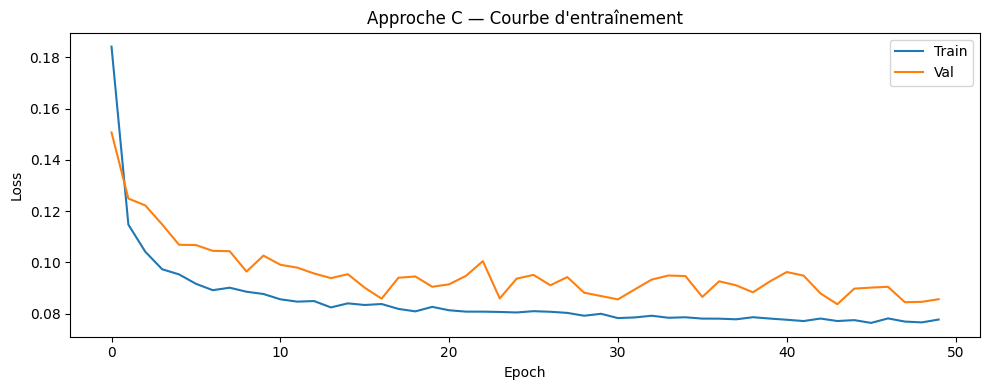

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Approche C — Courbe d\'entraînement')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'loss_curve.png'), dpi=150)
plt.show()

## 7. Ablation — avec vs sans velocity injection
Requis par les instructions. On compare :
- **Baseline** : BiGRU reçoit `X` seulement
- **Ours** : BiGRU reçoit `[X, Vel(X)]`

In [10]:
# ── Modèle SANS vélocité (baseline pour ablation) ─────────────────────────────
_orig_vel = VelocityGuidedTimingSAM.compute_velocity
VelocityGuidedTimingSAM.compute_velocity = staticmethod(lambda x: torch.zeros_like(x))
model_base = SignSAM_C(n_keypoints=N_KEYPOINTS, model_channels=MODEL_CHANNELS).to(DEVICE)
VelocityGuidedTimingSAM.compute_velocity = staticmethod(_orig_vel)  # restaurer

# ── Modèle AVEC vélocité (ours) ───────────────────────────────────────────────
model_vel = SignSAM_C(n_keypoints=N_KEYPOINTS, model_channels=MODEL_CHANNELS).to(DEVICE)

opt_base = torch.optim.AdamW(model_base.parameters(), lr=LEARNING_RATE)
opt_vel  = torch.optim.AdamW(model_vel.parameters(),  lr=LEARNING_RATE)

ABLATION_EPOCHS = 10
abl = {'base': {'train': [], 'val': []}, 'vel': {'train': [], 'val': []}}

for ep in range(ABLATION_EPOCHS):
    tl_b = train_one_epoch(model_base, train_loader, opt_base, diffusion, DEVICE)
    vl_b = validate(model_base, dev_loader, diffusion, DEVICE)
    abl['base']['train'].append(tl_b)
    abl['base']['val'].append(vl_b)

    tl_v = train_one_epoch(model_vel, train_loader, opt_vel, diffusion, DEVICE)
    vl_v = validate(model_vel, dev_loader, diffusion, DEVICE)
    abl['vel']['train'].append(tl_v)
    abl['vel']['val'].append(vl_v)

    print(f'Ep {ep+1:02d}  Baseline={vl_b:.4f}  Velocity-Guided={vl_v:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key in zip(axes, ['train', 'val']):
    ax.plot(abl['base'][key], '--', label='Baseline (sans vélocité)')
    ax.plot(abl['vel'][key],        label='Velocity-Guided (ours)')
    ax.set_title(f'{key.capitalize()} loss')
    ax.legend()
plt.suptitle('Ablation : Velocity-Guided Timing-SAM')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation.png'), dpi=150)
plt.show()

print(f"\nVal finale — Baseline       : {abl['base']['val'][-1]:.4f}")
print(f"Val finale — Velocity-Guided: {abl['vel']['val'][-1]:.4f}")

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Ep 01  Baseline=0.1390  Velocity-Guided=0.1487


Ep 02  Baseline=0.1255  Velocity-Guided=0.1250


Ep 03  Baseline=0.1211  Velocity-Guided=0.1230


Ep 04  Baseline=0.1133  Velocity-Guided=0.1132
